In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
# Load dataset
df = pd.read_csv('housing_data_cleaned_STD.csv') 

In [0]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
19675,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
19676,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
19677,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
19678,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [0]:
# Data types
print(df.dtypes)


MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Target        float64
dtype: object


In [0]:
# Null values
print(df.isnull().sum())


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64


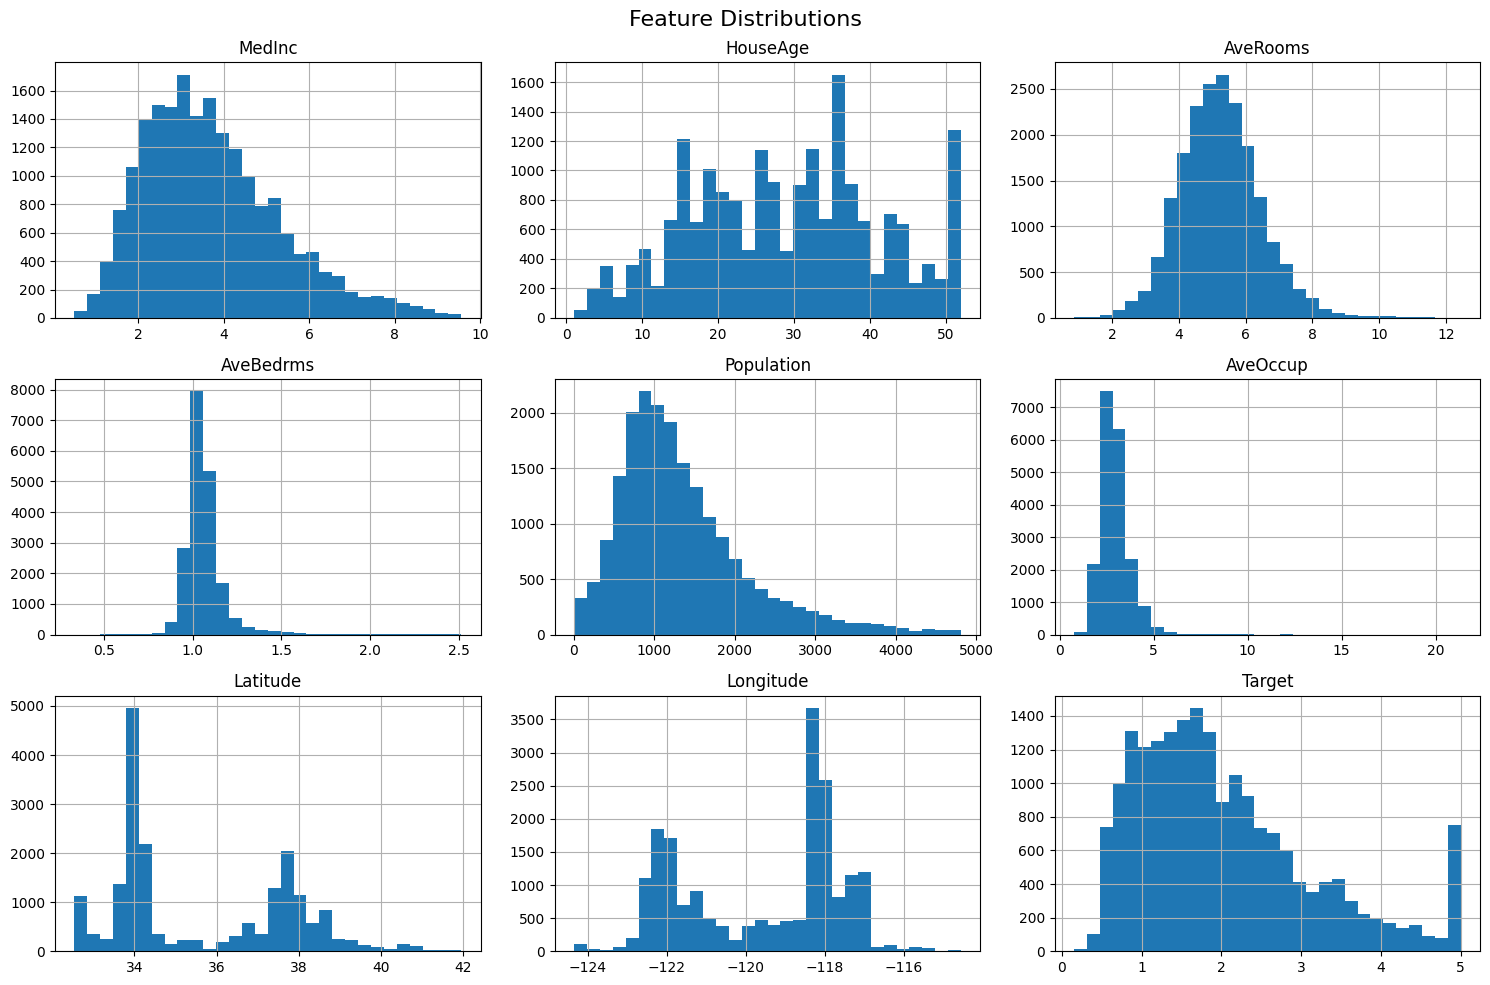

In [0]:
# Distribution plots
df.hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


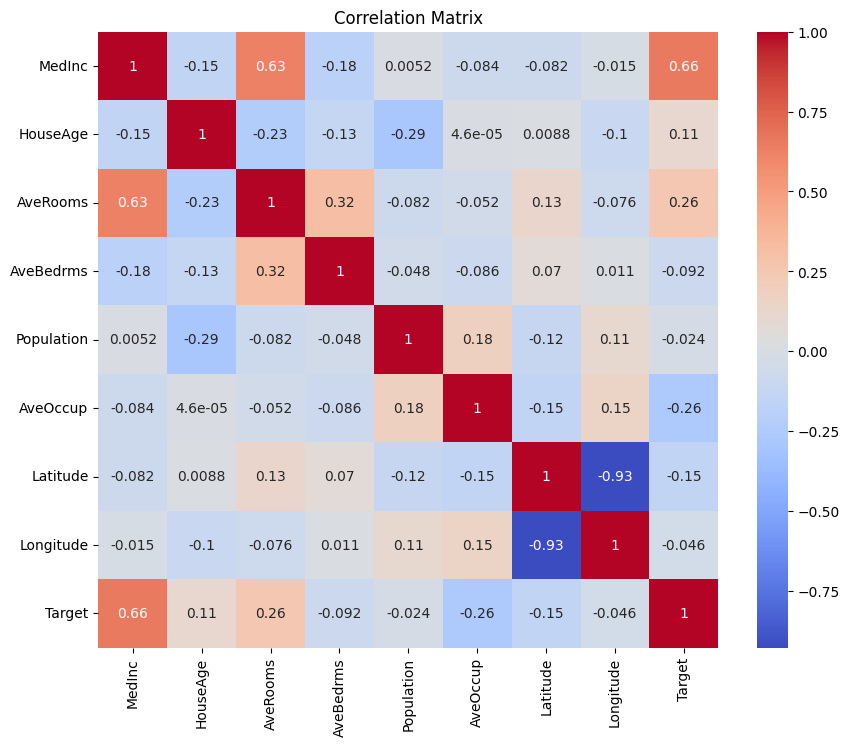

In [0]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


-- No null values.
--	All columns are float64 (numeric).
--	Strongest correlation to target is MedInc (median income).
--	No extreme outliers (already removed).


In [0]:
# Select relevant columns
df_reg = df[['MedInc', 'Target']].dropna()


print("Shape of regression dataset:", df_reg.shape)


Shape of regression dataset: (19680, 2)


In [0]:
from sklearn.linear_model import LinearRegression
import numpy as np


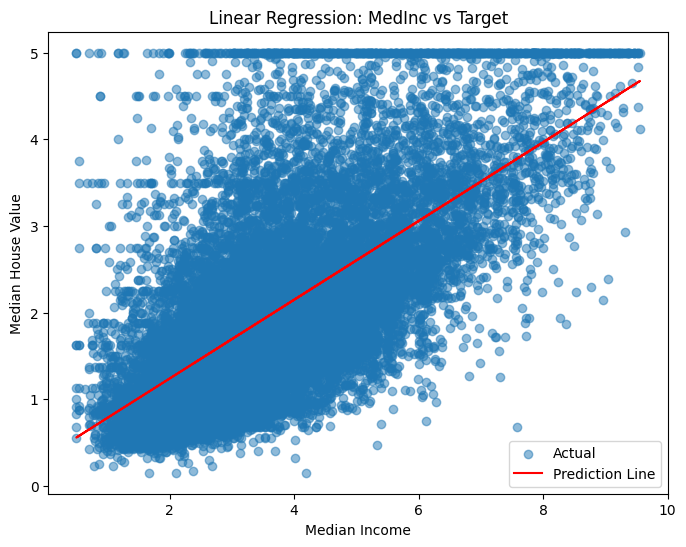

In [0]:
X = df_reg[['MedInc']]
y = df_reg['Target']

# Fit the model
model = LinearRegression()
model.fit(X, y)

# Predicting values
y_pred = model.predict(X)

# Plot actual v predicted
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Actual', alpha=0.5)
plt.plot(X, y_pred, color='red', label='Prediction Line')
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression: MedInc vs Target")
plt.legend()
plt.show()


In [0]:
from scipy.stats import pearsonr

In [0]:
corr_coef, p_value = pearsonr(df_reg['MedInc'], df_reg['Target'])
print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-Value: {p_value:.4e}")


Pearson Correlation Coefficient: 0.6586
P-Value: 0.0000e+00


In [0]:
from sklearn.metrics import r2_score

In [0]:
r2 = r2_score(y, y_pred)
residuals = y - y_pred

print(f"R² Score: {r2:.4f}")


R² Score: 0.4337


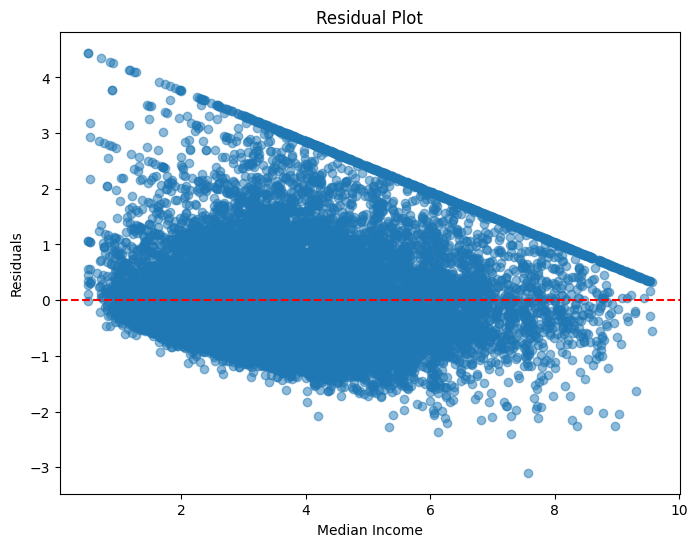

In [0]:
plt.figure(figsize=(8, 6))
plt.scatter(X, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Median Income")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
